# Laboratorio 1 - Análisis Estadístico Descriptivo e Inferencial
**Dataset**: Diabetic Retinopathy Debrecen  
**Integrantes**: Gonzalo Ahumada, Daniel Muñoz  
**Curso**: Inteligencia Computacional - USACH 2026

## 1. Carga del Dataset

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Descargar el dataset directamente desde UCI Machine Learning Repository
# DOI: https://doi.org/10.24432/C5XP4P
repo = fetch_ucirepo(id=329)

# Unir atributos con la variable objetivo en un único DataFrame
df = pd.concat([repo.data.features, repo.data.targets], axis=1)

# Renombrar columnas con nombres descriptivos
df.columns = [
    'quality', 'pre_screening',
    'ma1', 'ma2', 'ma3', 'ma4', 'ma5', 'ma6',
    'exudate1', 'exudate2', 'exudate3', 'exudate4',
    'exudate5', 'exudate6', 'exudate7', 'exudate8',
    'macula_opticdisc_distance', 'opticdisc_diameter',
    'am_fm_classification', 'Class'
]

print(f'Instancias: {df.shape[0]}, Variables: {df.shape[1]}')
df.head()

Instancias: 1151, Variables: 20


,quality,pre_screening,ma1,ma2,ma3,ma4,ma5,ma6,exudate1,exudate2,exudate3,exudate4,exudate5,exudate6,exudate7,exudate8,macula_opticdisc_distance,opticdisc_diameter,am_fm_classification,Class
0,1,1,22,22,22,19,18,14,49.895756,17.775994,5.270920,5.270920,0.018632,0.006864,0.003923,0.003923,0.486903,0.100025,1,0
1,1,1,24,24,22,18,16,13,57.709936,23.799994,3.325423,3.325423,0.003903,0.003903,0.003903,0.003903,0.520908,0.144414,0,0
2,1,1,62,60,59,54,47,33,55.831441,27.993933,12.687485,12.687485,1.393889,0.373252,0.041817,0.007744,0.530904,0.128548,0,1
3,1,1,55,53,53,50,43,31,40.467228,18.445954,9.118901,9.118901,0.840261,0.272434,0.007653,0.001531,0.483284,0.114790,0,0
4,1,1,44,44,44,41,39,27,18.026254,8.570709,0.410381,0.410381,0.000000,0.000000,0.000000,0.000000,0.475935,0.123572,0,1


## 2. Estadística Descriptiva

Calculamos las métricas básicas para las 19 variables.

In [2]:
# Separar la variable objetivo del resto de los atributos
X = df.drop(columns=['Class'])
y = df['Class']

# Calcular estadísticos: conteo, media, desviación estándar, mínimo y máximo
tabla_descriptiva = X.agg(['count', 'mean', 'std', 'min', 'max']).T
tabla_descriptiva.columns = ['count', 'mean', 'std', 'min', 'max']

print('Tabla de estadísticos descriptivos:')
print(tabla_descriptiva.round(4).to_string())

Tabla de estadísticos descriptivos:
                            count     mean      std     min       max
quality                    1151.0   0.9965   0.0589  0.0000    1.0000
pre_screening              1151.0   0.9183   0.2740  0.0000    1.0000
ma1                        1151.0  38.4283  25.6209  1.0000  151.0000
ma2                        1151.0  36.9096  24.1056  1.0000  132.0000
ma3                        1151.0  35.1407  22.8054  1.0000  120.0000
ma4                        1151.0  32.2971  21.1148  1.0000  105.0000
ma5                        1151.0  28.7472  19.5092  1.0000   97.0000
ma6                        1151.0  21.1512  15.1016  1.0000   89.0000
exudate1                   1151.0  64.0967  58.4853  0.3493  403.9391
exudate2                   1151.0  23.0880  21.6027  0.0000  167.1314
exudate3                   1151.0   8.7046  11.5676  0.0000  106.0701
exudate4                   1151.0   8.7046  11.5676  0.0000  106.0701
exudate5                   1151.0   0.5607   2.4841  0

## 3. Asimetría y Curtosis de Microaneurismas (ma1 - ma6)

Los microaneurismas son la variable de mayor importancia diagnóstica según la literatura.
Analizamos la forma de su distribución.

In [3]:
# Seleccionar solo las variables de microaneurismas
ma_vars = ['ma1', 'ma2', 'ma3', 'ma4', 'ma5', 'ma6']

# Calcular asimetría (skewness) y curtosis para cada variable
tabla_forma = pd.DataFrame({
    'Asimetría (skew)': df[ma_vars].skew(),
    'Curtosis':         df[ma_vars].kurt()
})

print('Asimetría y curtosis de microaneurismas:')
print(tabla_forma.round(6).to_string())

Asimetría y curtosis de microaneurismas:
     Asimetría (skew)  Curtosis
ma1          0.743916  0.333756
ma2          0.625170 -0.099993
ma3          0.532673 -0.468193
ma4          0.498474 -0.673164
ma5          0.533248 -0.692618
ma6          0.722384 -0.102349


## 4. Prueba de Normalidad (Shapiro-Wilk)

Hipótesis nula (H0): los datos siguen una distribución normal.  
Si p-valor < 0.05, se rechaza H0 → distribución NO normal.

In [4]:
resultados_normalidad = []

for var in ma_vars:
    W, p = stats.shapiro(df[var])
    resultados_normalidad.append({
        'Variable':     var,
        'W':            round(W, 6),
        'p-value':      p,
        'Distribución': 'No Normal' if p < 0.05 else 'Normal'
    })

tabla_normalidad = pd.DataFrame(resultados_normalidad).set_index('Variable')
print('Resultados del test de Shapiro-Wilk:')
print(tabla_normalidad.to_string())

Resultados del test de Shapiro-Wilk:
                 W       p-value Distribución
Variable                                     
ma1       0.945107  2.936420e-20    No Normal
ma2       0.950456  3.019064e-19    No Normal
ma3       0.950985  3.838923e-19    No Normal
ma4       0.947417  7.863389e-20    No Normal
ma5       0.938654  2.182104e-21    No Normal
ma6       0.929734  8.228670e-23    No Normal


## 5. Detección de Outliers (Método de Tukey)

Se identifican valores fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR].  
Se verifica la clase diagnóstica de cada outlier detectado.

In [5]:
def detectar_outliers_tukey(serie):
    """Retorna los índices de los outliers usando el método de Tukey."""
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    return serie[(serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)].index.tolist()

print('Outliers por variable de microaneurismas:\n')
for var in ma_vars:
    indices = detectar_outliers_tukey(df[var])
    clases  = df.loc[indices, 'Class'].tolist() if indices else []
    print(f'{var}: {len(indices)} outlier(s) | índices: {indices}')
    print(f'       Clase de cada outlier: {clases}\n')

Outliers por variable de microaneurismas:

ma1: 7 outlier(s) | índices: [129, 280, 332, 339, 560, 575, 1077]
       Clase de cada outlier: [1, 1, 1, 1, 1, 1, 1]

ma2: 6 outlier(s) | índices: [129, 280, 332, 339, 575, 1077]
       Clase de cada outlier: [1, 1, 1, 1, 1, 1]

ma3: 4 outlier(s) | índices: [332, 339, 575, 1077]
       Clase de cada outlier: [1, 1, 1, 1]

ma4: 1 outlier(s) | índices: [339]
       Clase de cada outlier: [1]

ma5: 1 outlier(s) | índices: [271]
       Clase de cada outlier: [1]

ma6: 3 outlier(s) | índices: [14, 271, 648]
       Clase de cada outlier: [0, 1, 1]



## 6. Visualización: Boxplot por Clase (Clase 0 vs Clase 1)

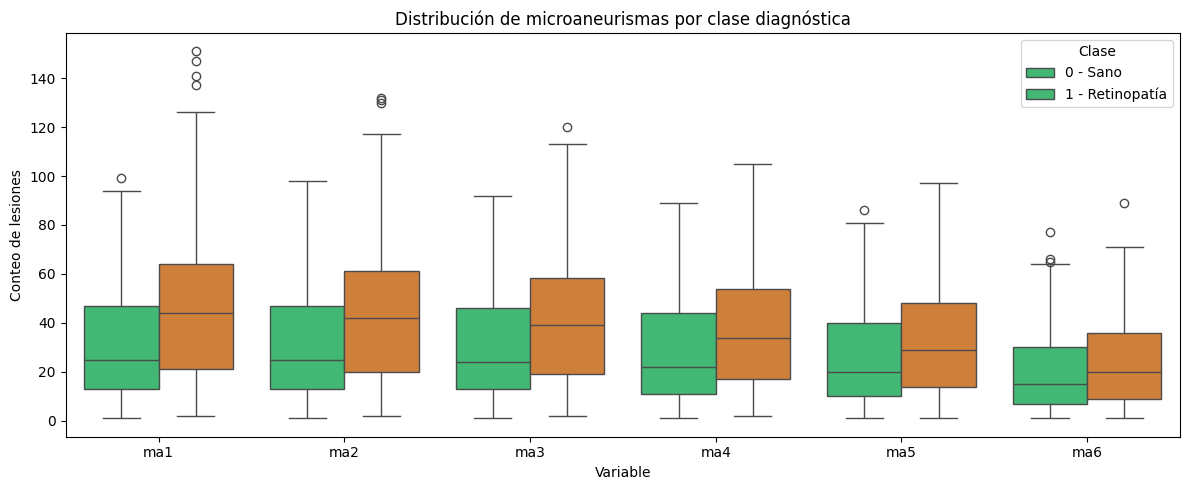

In [6]:
# Convertir a formato largo para facilitar el gráfico
df_ma = df[ma_vars + ['Class']].melt(id_vars='Class', var_name='Variable', value_name='Conteo')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_ma, x='Variable', y='Conteo',
    hue='Class', palette={0: '#2ecc71', 1: '#e67e22'},
    ax=ax
)
ax.set_title('Distribución de microaneurismas por clase diagnóstica')
ax.set_xlabel('Variable')
ax.set_ylabel('Conteo de lesiones')
ax.legend(title='Clase', labels=['0 - Sano', '1 - Retinopatía'])
plt.tight_layout()
plt.savefig('../informe/images/1-boxplot.png', dpi=150)
plt.show()

## 7. Mapa de Calor de Correlaciones (Heatmap)

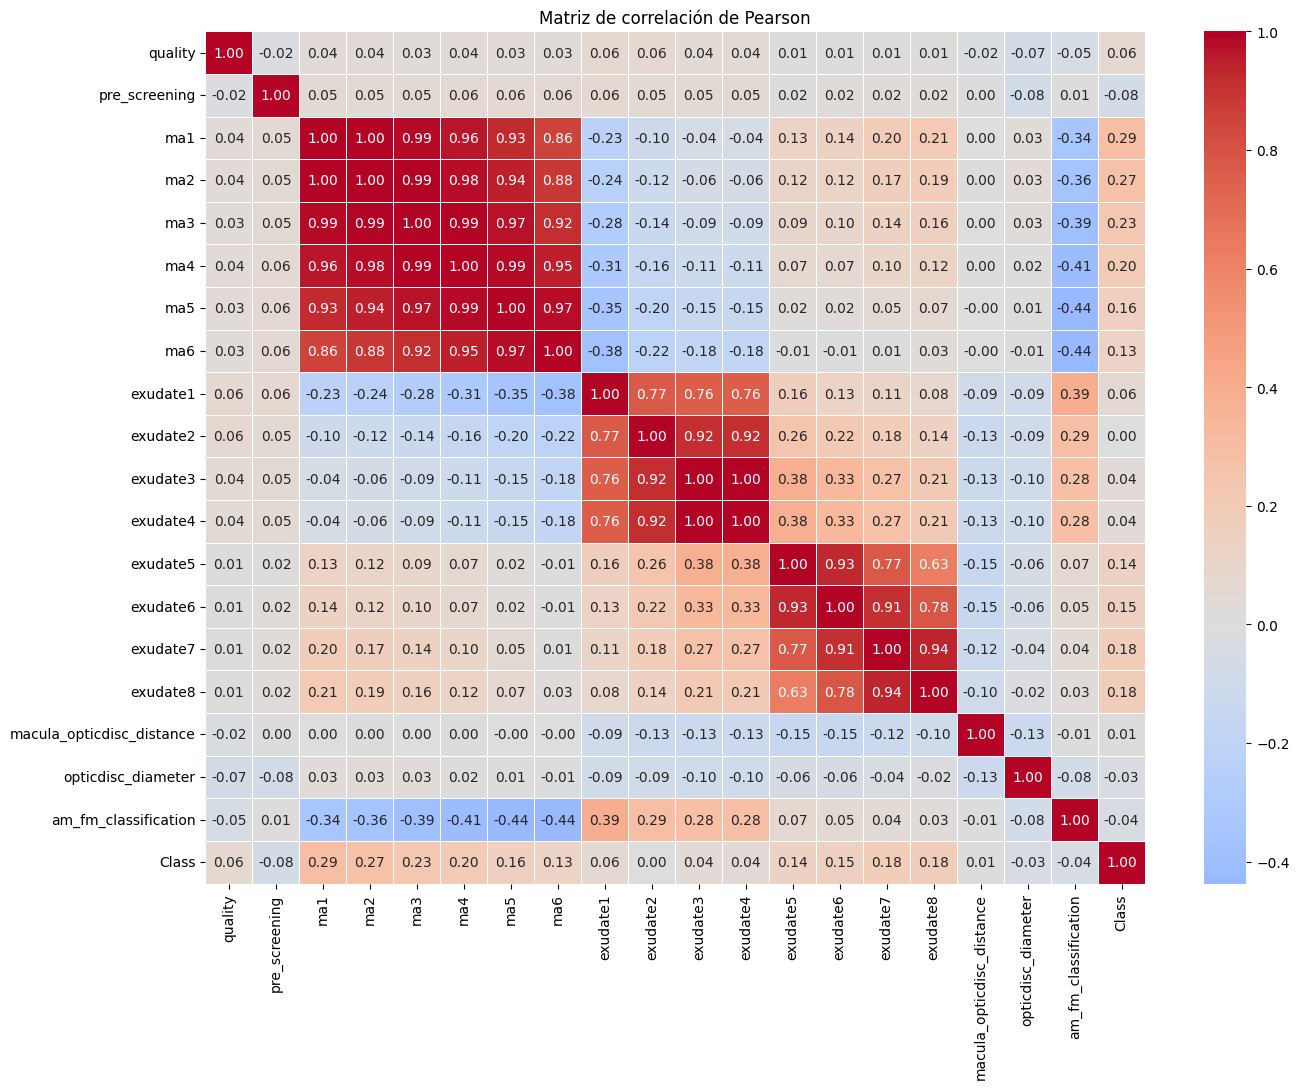

In [7]:
# Calcular la matriz de correlación de Pearson incluyendo la variable Class
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax
)
ax.set_title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.savefig('../informe/images/1-heatmap.png', dpi=150)
plt.show()

## 8. Comparación de Grupos: Prueba Mann-Whitney U

Como los datos NO son normales (confirmado en sección 4), usamos una prueba no paramétrica.  
H0: no hay diferencia entre Clase 0 y Clase 1.  
Si p-valor < 0.05, se rechaza H0 → diferencia estadísticamente significativa.

In [8]:
grupo_sano = df[df['Class'] == 0]
grupo_rd   = df[df['Class'] == 1]

resultados_mw = []

for var in ma_vars:
    U, p = stats.mannwhitneyu(
        grupo_sano[var], grupo_rd[var], alternative='two-sided'
    )
    resultados_mw.append({
        'Variable':      var,
        'U_statistic':   U,
        'p_value':       p,
        'Significativo': 'Sí' if p < 0.05 else 'No'
    })

tabla_mw = pd.DataFrame(resultados_mw).set_index('Variable')
print('Resultados de la prueba Mann-Whitney U:')
print(tabla_mw.to_string())

Resultados de la prueba Mann-Whitney U:
          U_statistic       p_value Significativo
Variable                                         
ma1          111207.5  1.251441e-21            Sí
ma2          116075.5  3.668012e-18            Sí
ma3          121531.5  1.170716e-14            Sí
ma4          127750.0  3.733250e-11            Sí
ma5          133505.5  2.248295e-08            Sí
ma6          139938.5  8.618494e-06            Sí


## 9. Prueba de Homogeneidad de Varianzas (Test de Levene)

Evalúa si las varianzas de los microaneurismas son iguales entre Clase 0 y Clase 1.  
Se usa el test de Levene porque los datos no siguen una distribución normal.  
H0: las varianzas de ambos grupos son iguales (homocedasticidad).  
Si p-valor < 0.05, se rechaza H0 → varianzas significativamente distintas.

In [9]:
resultados_levene = []

for var in ma_vars:
    stat, p = stats.levene(grupo_sano[var], grupo_rd[var])
    resultados_levene.append({
        'Variable':        var,
        'Estadístico':     round(stat, 4),
        'p_value':         p,
        'Homocedasticidad': 'Sí (varianzas iguales)' if p >= 0.05 else 'No (varianzas distintas)'
    })

tabla_levene = pd.DataFrame(resultados_levene).set_index('Variable')
print('Resultados del Test de Levene:')
print(tabla_levene.to_string())

Resultados del Test de Levene:
          Estadístico       p_value          Homocedasticidad
Variable                                                     
ma1           35.9975  2.644213e-09  No (varianzas distintas)
ma2           23.6750  1.299357e-06  No (varianzas distintas)
ma3           16.6036  4.922700e-05  No (varianzas distintas)
ma4           10.6155  1.154248e-03  No (varianzas distintas)
ma5            5.9695  1.470491e-02  No (varianzas distintas)
ma6            4.5424  3.327783e-02  No (varianzas distintas)


## 10. Regresión Logística

Modelo para predecir la presencia de retinopatía diabética.  
Se usan 4 variables para evitar multicolinealidad: ma1, exudate1, macula_opticdisc_distance, opticdisc_diameter.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Variables seleccionadas para el modelo
features = ['ma1', 'exudate1', 'macula_opticdisc_distance', 'opticdisc_diameter']

X_model = df[features]
y_model = df['Class']

# División 80% entrenamiento / 20% prueba (semilla=42 para reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

# Entrenar modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

# Predicciones
y_pred      = modelo.predict(X_test)
y_pred_prob = modelo.predict_proba(X_test)[:, 1]

# Métricas
auc = roc_auc_score(y_test, y_pred_prob)
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'AUC-ROC: {auc:.4f}')
print(f'\nMatriz de confusión:')
print(cm)
print(f'\nVerdaderos Positivos (TP): {tp}')
print(f'Verdaderos Negativos (TN): {tn}')
print(f'Falsos Positivos  (FP): {fp}')
print(f'Falsos Negativos  (FN): {fn}')
print(f'Sensibilidad: {tp/(tp+fn):.1%}')
print(f'Especificidad: {tn/(tn+fp):.1%}')

AUC-ROC: 0.6541

Matriz de confusión:
[[58 45]
 [49 79]]

Verdaderos Positivos (TP): 79
Verdaderos Negativos (TN): 58
Falsos Positivos  (FP): 45
Falsos Negativos  (FN): 49
Sensibilidad: 61.7%
Especificidad: 56.3%


## 11. Gráficos: Matriz de Confusión y Curva ROC

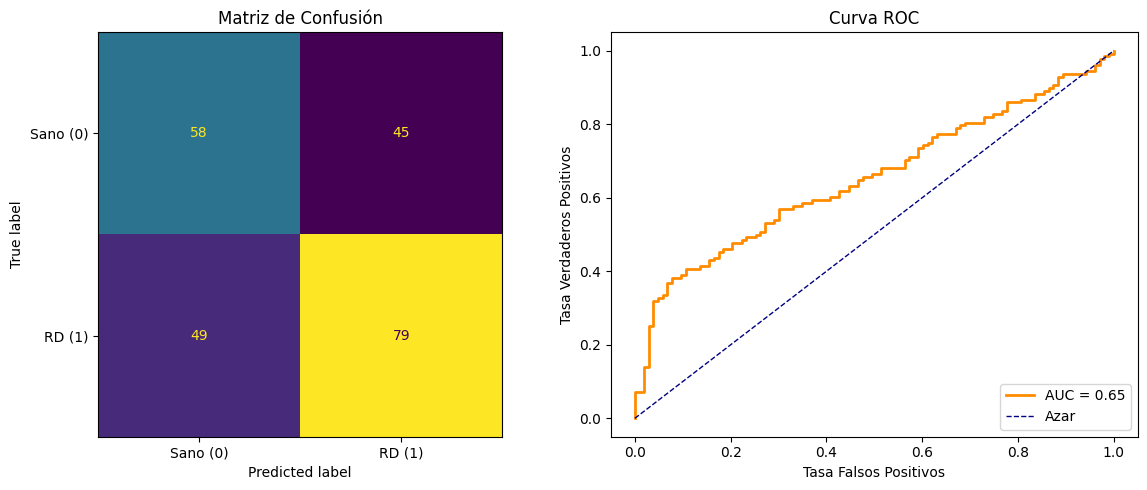

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
ConfusionMatrixDisplay(cm, display_labels=['Sano (0)', 'RD (1)']).plot(ax=ax1, colorbar=False)
ax1.set_title('Matriz de Confusión')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.2f}')
ax2.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Azar')
ax2.set_xlabel('Tasa Falsos Positivos')
ax2.set_ylabel('Tasa Verdaderos Positivos')
ax2.set_title('Curva ROC')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../informe/images/1-matrix-rocauc.png', dpi=150)
plt.show()

## 12. Histograma de Residuos del Modelo

Los residuos se calculan como la diferencia entre la clase real y la probabilidad predicha.  
Un histograma centrado en cero indica que el modelo no tiene sesgo sistemático.

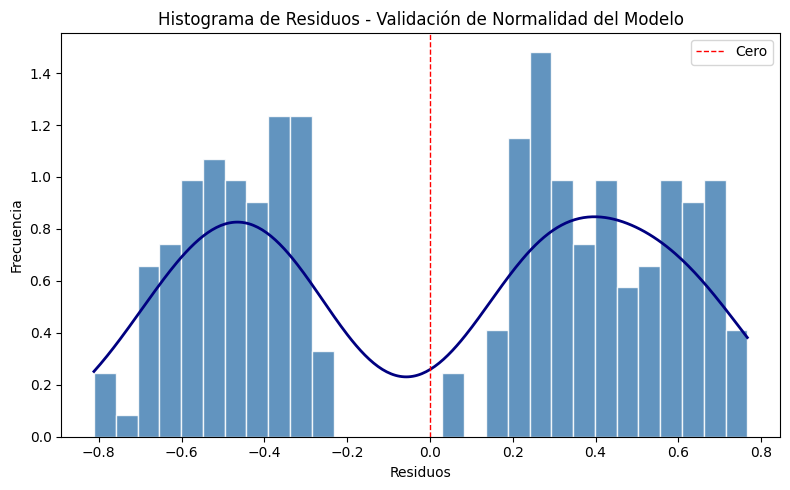

In [12]:
from scipy.stats import gaussian_kde

# Residuos: valor real menos probabilidad predicha
residuos = y_test.values - y_pred_prob

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuos, bins=30, density=True, color='steelblue', edgecolor='white', alpha=0.85)

# Curva de densidad suavizada
kde = gaussian_kde(residuos)
x_range = np.linspace(residuos.min(), residuos.max(), 300)
ax.plot(x_range, kde(x_range), color='navy', lw=2)

ax.set_title('Histograma de Residuos - Validación de Normalidad del Modelo')
ax.set_xlabel('Residuos')
ax.set_ylabel('Frecuencia')
ax.axvline(0, color='red', linestyle='--', lw=1, label='Cero')
ax.legend()
plt.tight_layout()
plt.savefig('../informe/images/1-histograms.png', dpi=150)
plt.show()